In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_theme(style="darkgrid")

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

from collections import Counter
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [211]:
df = pd.read_csv('churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [212]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [213]:
df.shape

(7043, 21)

In [214]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [215]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Convert TotalCharges to numeric, coercing errors to NaN
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [216]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


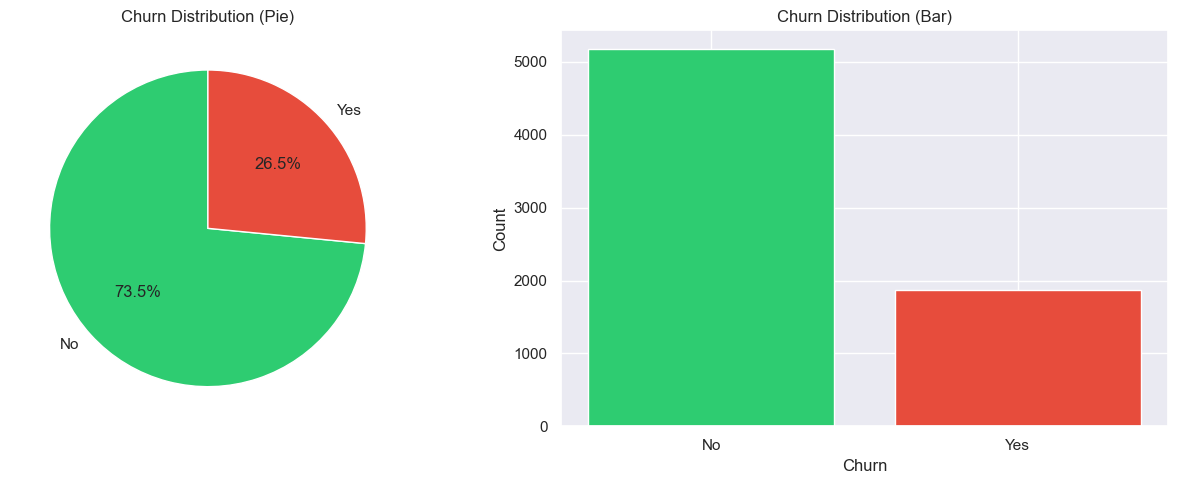

In [217]:
churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#e74c3c']

# Pie chart
axes[0].pie(
    churn_counts,
    labels=churn_counts.index, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Churn Distribution (Pie)')

# Bar chart
axes[1].bar(['No', 'Yes'], churn_counts.values, color=colors)
axes[1].set_title('Churn Distribution (Bar)')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [218]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_str_cols = [
    col for col in df.columns 
    if df[col].dtype in ['object', 'string'] and df[col].nunique() >= 3
]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[multi_str_cols])
df = pd.concat([df.drop(multi_str_cols, axis=1), ohetransform], axis=1)


df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [219]:
X = df.drop('Churn', axis=1)
y = df['Churn'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify= y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 40), (1409, 40), (5634,), (1409,))

In [220]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

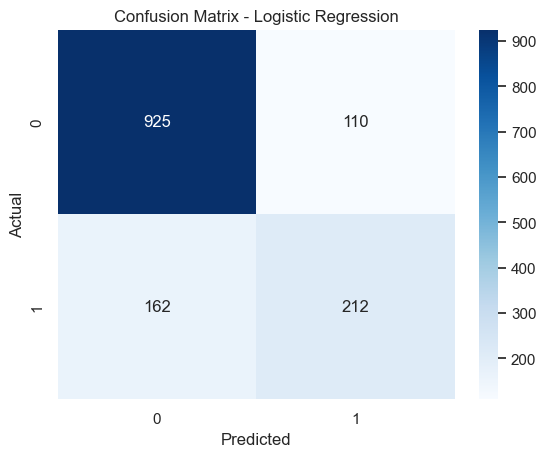

In [221]:
lr = LogisticRegression()

lr.fit(X_train, y_train)
lr_ypred = lr.predict(X_test)

lr_cmatrix = confusion_matrix(y_test, lr_ypred)
sns.heatmap(lr_cmatrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [222]:
lr_report = classification_report(y_test, lr_ypred)

lr_f1score = f1_score(y_test, lr_ypred, average='weighted')
lr_accuracy = accuracy_score(y_test, lr_ypred)
lr_roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
lr_avg_precision = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])

print("Classification Report - Logistic Regression:\n", lr_report)
print("F1 Score - Logistic Regression:", lr_f1score)
print("Accuracy - Logistic Regression:", lr_accuracy)
print("ROC AUC Score - Logistic Regression:", lr_roc_auc)
print("Average Precision Score - Logistic Regression:", lr_avg_precision)


Classification Report - Logistic Regression:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

F1 Score - Logistic Regression: 0.8021091451064993
Accuracy - Logistic Regression: 0.8069552874378992
ROC AUC Score - Logistic Regression: 0.8415949779121135
Average Precision Score - Logistic Regression: 0.6311000729747755


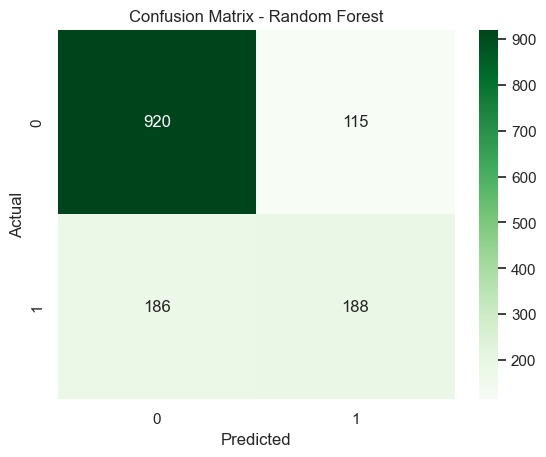

In [223]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_ypred = rf.predict(X_test)

rf_cmatrix = confusion_matrix(y_test, rf_ypred)
sns.heatmap(rf_cmatrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [224]:
rf_report = classification_report(y_test, rf_ypred)
rf_f1score = f1_score(y_test, rf_ypred, average='weighted')
rf_accuracy = accuracy_score(y_test, rf_ypred)
rf_roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
rf_avg_precision = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Classification Report - Random Forest:\n", rf_report)
print("F1 Score - Random Forest:", rf_f1score)
print("Accuracy - Random Forest:", rf_accuracy)
print("ROC AUC Score - Random Forest:", rf_roc_auc)
print("Average Precision Score - Random Forest:", rf_avg_precision)

Classification Report - Random Forest:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

F1 Score - Random Forest: 0.7787134762034057
Accuracy - Random Forest: 0.7863733144073811
ROC AUC Score - Random Forest: 0.8210454932961327
Average Precision Score - Random Forest: 0.6131288261918474


<Axes: >

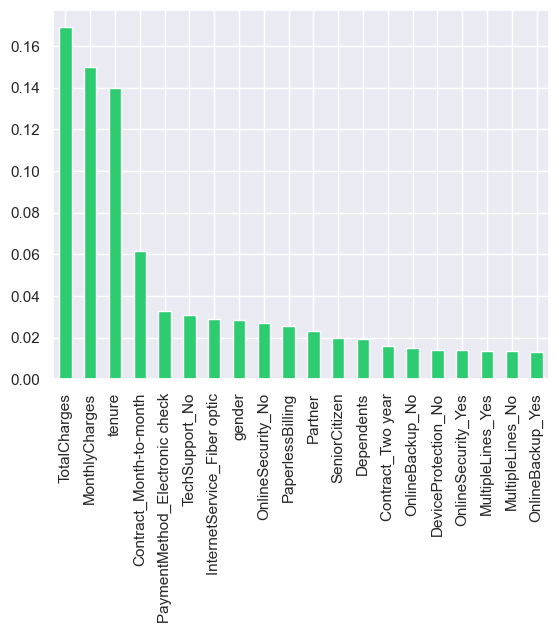

In [225]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp.head(20).plot(kind='bar', color = '#2ecc71')

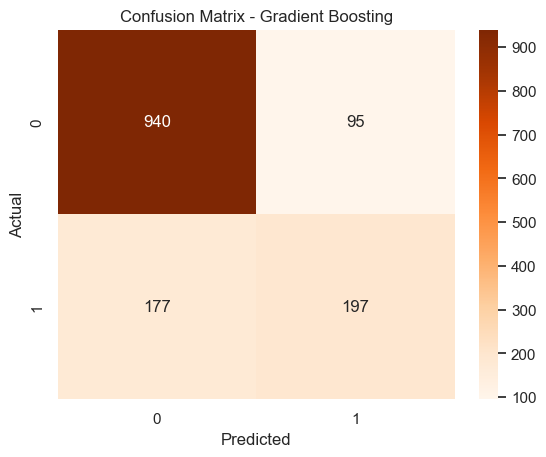

In [226]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_ypred = gb.predict(X_test)

gb_cmatrix = confusion_matrix(y_test, gb_ypred)
sns.heatmap(gb_cmatrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [227]:
gb_report = classification_report(y_test, gb_ypred)
gb_f1score = f1_score(y_test, gb_ypred, average='weighted')
gb_accuracy = accuracy_score(y_test, gb_ypred)
gb_roc_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
gb_avg_precision = average_precision_score(y_test, gb.predict_proba(X_test)[:, 1])

print("Classification Report - Gradient Boosting:\n", gb_report)
print("F1 Score - Gradient Boosting:", gb_f1score)
print("Accuracy - Gradient Boosting:", gb_accuracy)
print("ROC AUC Score - Gradient Boosting:", gb_roc_auc)
print("Average Precision Score - Gradient Boosting:", gb_avg_precision)

Classification Report - Gradient Boosting:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

F1 Score - Gradient Boosting: 0.7987490499567667
Accuracy - Gradient Boosting: 0.8069552874378992
ROC AUC Score - Gradient Boosting: 0.8433103412643055
Average Precision Score - Gradient Boosting: 0.6643955357113717


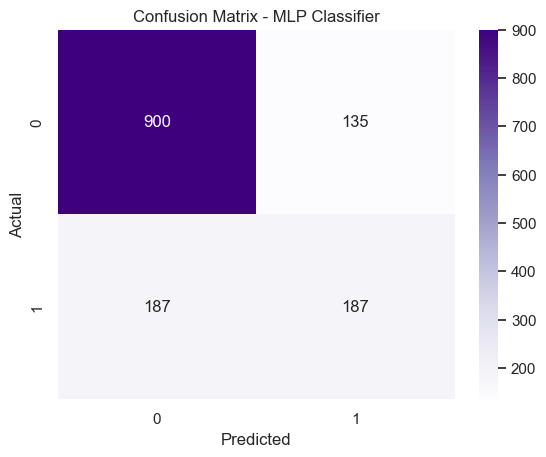

In [228]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  # One hidden layer with 100 neurons
    activation='relu',          # ReLU activation function
    solver='adam',             # Adam optimizer
    max_iter=200,              # Maximum number of iterations
    random_state=42            # For reproducibility
)

mlp.fit(X_train, y_train)
mlp_ypred = mlp.predict(X_test)

mlp_cmatrix = confusion_matrix(y_test, mlp_ypred)
sns.heatmap(mlp_cmatrix, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - MLP Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [229]:
mlp_report = classification_report(y_test, mlp_ypred)
mlp_f1score = f1_score(y_test, mlp_ypred, average='weighted')
mlp_accuracy = accuracy_score(y_test, mlp_ypred)
mlp_roc_auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])
mlp_avg_precision = average_precision_score(y_test, mlp.predict_proba(X_test)[:, 1])

print("Classification Report - MLP Classifier:\n", mlp_report)
print("F1 Score - MLP Classifier:", mlp_f1score)
print("Accuracy - MLP Classifier:", mlp_accuracy)
print("ROC AUC Score - MLP Classifier:", mlp_roc_auc)
print("Average Precision Score - MLP Classifier:", mlp_avg_precision)

Classification Report - MLP Classifier:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409

F1 Score - MLP Classifier: 0.7657321497216647
Accuracy - MLP Classifier: 0.7714691270404542
ROC AUC Score - MLP Classifier: 0.8107210209511999
Average Precision Score - MLP Classifier: 0.578692621006309


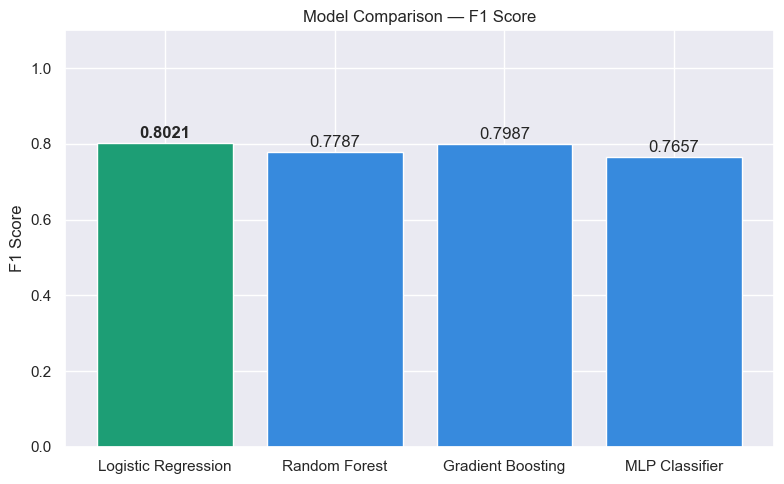

Best model: Logistic Regression  |  F1 = 0.8021


In [230]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'MLP Classifier']
F1_scores = [lr_f1score, rf_f1score, gb_f1score, mlp_f1score]

best_idx = int(np.argmax(F1_scores))
colors   = ['#1D9E75' if i == best_idx else '#378ADD' for i in range(4)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, F1_scores, color=colors)

for i, (bar, score) in enumerate(zip(bars, F1_scores)):
    label = f'{score:.4f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            label, ha='center', va='bottom', fontweight='bold' if i == best_idx else 'normal')

ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Model Comparison — F1 Score')
plt.tight_layout()
plt.show()

print(f"Best model: {models[best_idx]}  |  F1 = {F1_scores[best_idx]:.4f}")

In [231]:
counter = Counter(y_train)
print("Original class distribution:", counter)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

counter_resampled = Counter(y_train_resampled)
print("\nResampled class distribution:", counter_resampled)

Original class distribution: Counter({0: 4139, 1: 1495})

Resampled class distribution: Counter({0: 4139, 1: 4139})


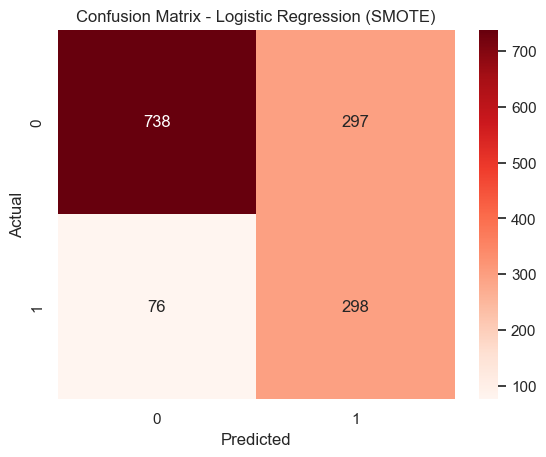

In [232]:
lrs = LogisticRegression()
lrs.fit(X_train_resampled, y_train_resampled)
lrs_ypred = lrs.predict(X_test)

lrs_cmatrix = confusion_matrix(y_test, lrs_ypred)
sns.heatmap(lrs_cmatrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Logistic Regression (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [233]:
lrs_report = classification_report(y_test, lrs_ypred)
lrs_f1score = f1_score(y_test, lrs_ypred, average='weighted')
lrs_accuracy = accuracy_score(y_test, lrs_ypred)
lrs_roc_auc = roc_auc_score(y_test, lrs.predict_proba(X_test)[:, 1])
lrs_avg_precision = average_precision_score(y_test, lrs.predict_proba(X_test)[:, 1])

print("Classification Report - Logistic Regression (SMOTE):\n", lrs_report)
print("F1 Score - Logistic Regression (SMOTE):", lrs_f1score)
print("Accuracy - Logistic Regression (SMOTE):", lrs_accuracy)
print("ROC AUC Score - Logistic Regression (SMOTE):", lrs_roc_auc)
print("Average Precision Score - Logistic Regression (SMOTE):", lrs_avg_precision)

Classification Report - Logistic Regression (SMOTE):
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

F1 Score - Logistic Regression (SMOTE): 0.7496407730390326
Accuracy - Logistic Regression (SMOTE): 0.7352732434350603
ROC AUC Score - Logistic Regression (SMOTE): 0.840243870934408
Average Precision Score - Logistic Regression (SMOTE): 0.6280776291525254


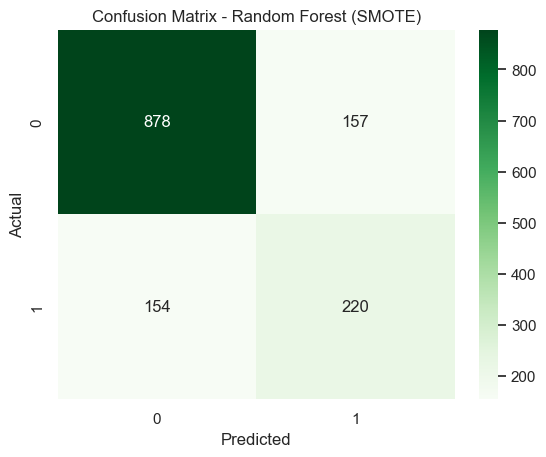

In [234]:
rfs = RandomForestClassifier()
rfs.fit(X_train_resampled, y_train_resampled)
rfs_ypred = rfs.predict(X_test)

rfs_cmatrix = confusion_matrix(y_test, rfs_ypred)
sns.heatmap(rfs_cmatrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [235]:
rfs_report = classification_report(y_test, rfs_ypred)
rfs_f1score = f1_score(y_test, rfs_ypred, average='weighted')
rfs_accuracy = accuracy_score(y_test, rfs_ypred)
rfs_roc_auc = roc_auc_score(y_test, rfs.predict_proba(X_test)[:, 1])
rfs_avg_precision = average_precision_score(y_test, rfs.predict_proba(X_test)[:, 1])    

print("Classification Report - Random Forest (SMOTE):\n", rfs_report)
print("F1 Score - Random Forest (SMOTE):", rfs_f1score)
print("Accuracy - Random Forest (SMOTE):", rfs_accuracy)
print("ROC AUC Score - Random Forest (SMOTE):", rfs_roc_auc)
print("Average Precision Score - Random Forest (SMOTE):", rfs_avg_precision)

Classification Report - Random Forest (SMOTE):
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

F1 Score - Random Forest (SMOTE): 0.7795567653414033
Accuracy - Random Forest (SMOTE): 0.7792760823278921
ROC AUC Score - Random Forest (SMOTE): 0.8183058203518562
Average Precision Score - Random Forest (SMOTE): 0.5946555757217663


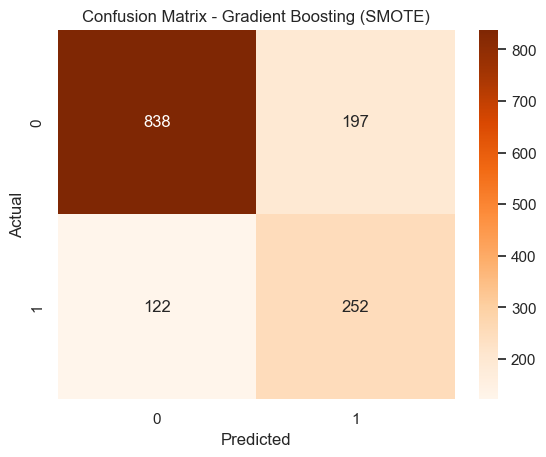

In [236]:
gbs = GradientBoostingClassifier()
gbs.fit(X_train_resampled, y_train_resampled)
gbs_ypred = gbs.predict(X_test)

gbs_cmatrix = confusion_matrix(y_test, gbs_ypred)
sns.heatmap(gbs_cmatrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [237]:
gbs_report = classification_report(y_test, gbs_ypred)
gbs_f1score = f1_score(y_test, gbs_ypred, average='weighted')
gbs_accuracy = accuracy_score(y_test, gbs_ypred)
gbs_roc_auc = roc_auc_score(y_test, gbs.predict_proba(X_test)[:, 1])
gbs_avg_precision = average_precision_score(y_test, gbs.predict_proba(X_test)[:, 1])

print("Classification Report - Gradient Boosting (SMOTE):\n", gbs_report)
print("F1 Score - Gradient Boosting (SMOTE):", gbs_f1score)
print("Accuracy - Gradient Boosting (SMOTE):", gbs_accuracy)
print("ROC AUC Score - Gradient Boosting (SMOTE):", gbs_roc_auc)
print("Average Precision Score - Gradient Boosting (SMOTE):", gbs_avg_precision)

Classification Report - Gradient Boosting (SMOTE):
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409

F1 Score - Gradient Boosting (SMOTE): 0.7796586205369254
Accuracy - Gradient Boosting (SMOTE): 0.7735982966643009
ROC AUC Score - Gradient Boosting (SMOTE): 0.838635717791728
Average Precision Score - Gradient Boosting (SMOTE): 0.6427654963388062


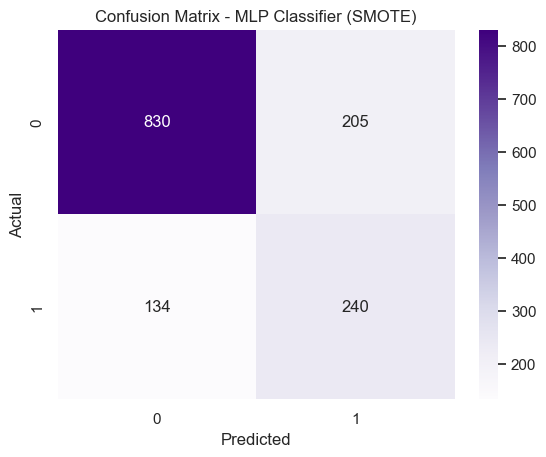

In [238]:
mlps = MLPClassifier(
    hidden_layer_sizes=(100,),  # One hidden layer with 100 neurons
    activation='relu',          # ReLU activation function
    solver='adam',             # Adam optimizer
    max_iter=200,              # Maximum number of iterations
    random_state=42            # For reproducibility
)
mlps.fit(X_train_resampled, y_train_resampled)
mlps_ypred = mlps.predict(X_test)

mlps_cmatrix = confusion_matrix(y_test, mlps_ypred)
sns.heatmap(mlps_cmatrix, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - MLP Classifier (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [239]:
mlps_report = classification_report(y_test, mlps_ypred)
mlps_f1score = f1_score(y_test, mlps_ypred, average='weighted')
mlps_accuracy = accuracy_score(y_test, mlps_ypred)
mlps_roc_auc = roc_auc_score(y_test, mlps.predict_proba(X_test)[:, 1])
mlps_avg_precision = average_precision_score(y_test, mlps.predict_proba(X_test)[:, 1])
mlps_recall = recall_score(y_test, mlps_ypred, average='weighted')

print("Classification Report - MLP Classifier (SMOTE):\n", mlps_report)
print("F1 Score - MLP Classifier (SMOTE):", mlps_f1score)
print("Accuracy - MLP Classifier (SMOTE):", mlps_accuracy)
print("ROC AUC Score - MLP Classifier (SMOTE):", mlps_roc_auc)
print("Average Precision Score - MLP Classifier (SMOTE):", mlps_avg_precision)
print("Recall Score - MLP Classifier (SMOTE):", mlps_recall)

Classification Report - MLP Classifier (SMOTE):
               precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.54      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

F1 Score - MLP Classifier (SMOTE): 0.7655598857800385
Accuracy - MLP Classifier (SMOTE): 0.759403832505323
ROC AUC Score - MLP Classifier (SMOTE): 0.7931721305122839
Average Precision Score - MLP Classifier (SMOTE): 0.569241448341365
Recall Score - MLP Classifier (SMOTE): 0.759403832505323


In [240]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'MLP Classifier']
f1_scores = [lr_f1score, rf_f1score, gb_f1score, mlp_f1score]
f1_scores_smote = [lrs_f1score, rfs_f1score, gbs_f1score, mlps_f1score]

compare_f1 = pd.DataFrame({'Algorithm': models, 'F1 Score Before SMOTE': f1_scores, 'F1 Score After SMOTE': f1_scores_smote})
compare_f1.sort_values(by='F1 Score After SMOTE', ascending=False).reset_index(drop=True) 

,Algorithm,F1 Score Before SMOTE,F1 Score After SMOTE
0,Gradient Boosting,0.798749,0.779659
1,Random Forest,0.778713,0.779557
2,MLP Classifier,0.765732,0.765560
3,Logistic Regression,0.802109,0.749641


HYPERPARAMETER TUNING

In [241]:
lrhp = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_grid_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs']
}

grid_searchlrhp = GridSearchCV(estimator=lrhp, param_grid=lr_grid_params, cv=5, scoring='recall', n_jobs=-1)
grid_searchlrhp.fit(X_train_resampled, y_train_resampled)

best_lr = grid_searchlrhp.best_estimator_
lrhp_pred = best_lr.predict(X_test)

print("Best Hyperparameters for Logistic Regression:", grid_searchlrhp.best_params_)
print("Best Cross-Validation Score:", grid_searchlrhp.best_score_)
print("Best Model:\n", grid_searchlrhp.best_estimator_)


Best Hyperparameters for Logistic Regression: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8137219681171104
Best Model:
 LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')


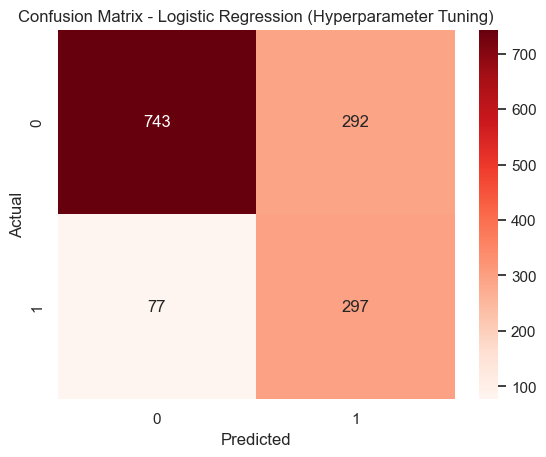

In [242]:
lrhp_cmatrix = confusion_matrix(y_test, lrhp_pred)
sns.heatmap(lrhp_cmatrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Logistic Regression (Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [243]:
lrhp_report = classification_report(y_test, grid_searchlrhp.predict(X_test))
lrhp_f1score = f1_score(y_test, grid_searchlrhp.predict(X_test), average='weighted')
lrhp_accuracy = accuracy_score(y_test, grid_searchlrhp.predict(X_test))
lrhp_roc_auc = roc_auc_score(y_test, grid_searchlrhp.predict_proba(X_test)[:, 1])
lrhp_avg_precision = average_precision_score(y_test, grid_searchlrhp.predict_proba(X_test)[:, 1])

print("Classification Report - Logistic Regression (Hyperparameter Tuning):\n", lrhp_report)
print("F1 Score - Logistic Regression (Hyperparameter Tuning):", lrhp_f1score)
print("Accuracy - Logistic Regression (Hyperparameter Tuning):", lrhp_accuracy)
print("ROC AUC Score - Logistic Regression (Hyperparameter Tuning):", lrhp_roc_auc)
print("Average Precision Score - Logistic Regression (Hyperparameter Tuning):", lrhp_avg_precision)

Classification Report - Logistic Regression (Hyperparameter Tuning):
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

F1 Score - Logistic Regression (Hyperparameter Tuning): 0.7521699728530917
Accuracy - Logistic Regression (Hyperparameter Tuning): 0.7381121362668559
ROC AUC Score - Logistic Regression (Hyperparameter Tuning): 0.83713477485856
Average Precision Score - Logistic Regression (Hyperparameter Tuning): 0.6317441286603102


In [244]:
rfhp = RandomForestClassifier(class_weight='balanced')

rf_grid_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_searchrfhp = GridSearchCV(estimator=rfhp, param_grid=rf_grid_params, cv=5, scoring='recall', n_jobs=-1)
grid_searchrfhp.fit(X_train_resampled, y_train_resampled)

best_rf = grid_searchrfhp.best_estimator_ 
rfhp_pred = best_rf.predict(X_test)

print("Best Hyperparameters for Random Forest:", grid_searchrfhp.best_params_)
print("Best Cross-Validation Score:", grid_searchrfhp.best_score_)
print("Best Model:\n", best_rf)

Best Hyperparameters for Random Forest: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.8794542873665948
Best Model:
 RandomForestClassifier(class_weight='balanced', max_depth=10,
                       max_features='log2')


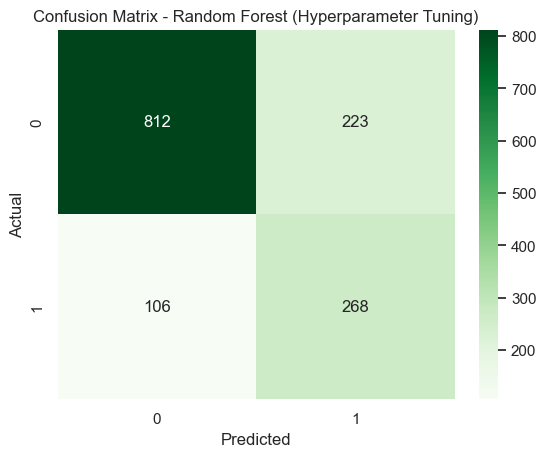

In [245]:
rfhp_cmatrix = confusion_matrix(y_test, rfhp_pred)
sns.heatmap(rfhp_cmatrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest (Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [246]:
rfhp_report = classification_report(y_test, best_rf.predict(X_test))
rfhp_f1score = f1_score(y_test, best_rf.predict(X_test), average='weighted')
rfhp_accuracy = accuracy_score(y_test, best_rf.predict(X_test))
rfhp_roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
rfhp_avg_precision = average_precision_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print("Classification Report - Random Forest (Hyperparameter Tuning):\n", rfhp_report)
print("F1 Score - Random Forest (Hyperparameter Tuning):", rfhp_f1score)
print("Accuracy - Random Forest (Hyperparameter Tuning):", rfhp_accuracy)
print("ROC AUC Score - Random Forest (Hyperparameter Tuning):", rfhp_roc_auc)
print("Average Precision Score - Random Forest (Hyperparameter Tuning):", rfhp_avg_precision)

Classification Report - Random Forest (Hyperparameter Tuning):
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

F1 Score - Random Forest (Hyperparameter Tuning): 0.7752984033411381
Accuracy - Random Forest (Hyperparameter Tuning): 0.7665010645848119
ROC AUC Score - Random Forest (Hyperparameter Tuning): 0.8351416983130537
Average Precision Score - Random Forest (Hyperparameter Tuning): 0.6296519355719996


In [247]:
gbhp = GradientBoostingClassifier()

gb_grid_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_searchgbhp = GridSearchCV(estimator=gbhp, param_grid=gb_grid_params, cv=5, scoring='recall', n_jobs=-1)
grid_searchgbhp.fit(X_train_resampled, y_train_resampled)

best_gb = grid_searchgbhp.best_estimator_
gbhp_pred = best_gb.predict(X_test)

print("Best Hyperparameters for Gradient Boosting:", grid_searchgbhp.best_params_)
print("Best Cross-Validation Score:", grid_searchgbhp.best_score_)
print("Best Model:\n", grid_searchgbhp.best_estimator_)

Best Hyperparameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.8680957888649388
Best Model:
 GradientBoostingClassifier(learning_rate=0.01, max_depth=5, max_features='sqrt',
                           min_samples_leaf=2, min_samples_split=5,
                           n_estimators=200)


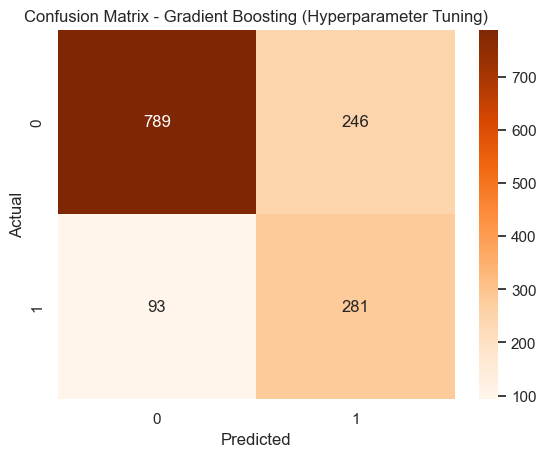

In [248]:
gbhp_cmatrix = confusion_matrix(y_test, gbhp_pred)
sns.heatmap(gbhp_cmatrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting (Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [249]:
gbhp_report = classification_report(y_test, grid_searchgbhp.predict(X_test))
gbhp_f1score = f1_score(y_test, grid_searchgbhp.predict(X_test), average='weighted')
gbhp_accuracy = accuracy_score(y_test, grid_searchgbhp.predict(X_test))
gbhp_roc_auc = roc_auc_score(y_test, grid_searchgbhp.predict_proba(X_test)[:, 1])
gbhp_avg_precision = average_precision_score(y_test, grid_searchgbhp.predict_proba(X_test)[:, 1])

print("Classification Report - Gradient Boosting (Hyperparameter Tuning):\n", gbhp_report)
print("F1 Score - Gradient Boosting (Hyperparameter Tuning):", gbhp_f1score)
print("Accuracy - Gradient Boosting (Hyperparameter Tuning):", gbhp_accuracy)
print("ROC AUC Score - Gradient Boosting (Hyperparameter Tuning):", gbhp_roc_auc)
print("Average Precision Score - Gradient Boosting (Hyperparameter Tuning):", gbhp_avg_precision)

Classification Report - Gradient Boosting (Hyperparameter Tuning):
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

F1 Score - Gradient Boosting (Hyperparameter Tuning): 0.770230553480369
Accuracy - Gradient Boosting (Hyperparameter Tuning): 0.759403832505323
ROC AUC Score - Gradient Boosting (Hyperparameter Tuning): 0.8388113875326151
Average Precision Score - Gradient Boosting (Hyperparameter Tuning): 0.6369268767800678


In [250]:
mlphp = MLPClassifier(max_iter=1000)

mlp_grid_params = {
    'hidden_layer_sizes': [(100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive']
}

grid_searchmlphp = GridSearchCV(estimator=mlphp, param_grid=mlp_grid_params, cv=5, scoring='recall', n_jobs=-1)
grid_searchmlphp.fit(X_train_resampled, y_train_resampled)

best_mlp = grid_searchmlphp.best_estimator_
mlphp_pred = best_mlp.predict(X_test)

print("Best Hyperparameters for MLP Classifier:", grid_searchmlphp.best_params_)
print("Best Cross-Validation Score:", grid_searchmlphp.best_score_)
print("Best Model:\n", grid_searchmlphp.best_estimator_)

Best Hyperparameters for MLP Classifier: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'adaptive', 'solver': 'adam'}
Best Cross-Validation Score: 0.9120682403659114
Best Model:
 MLPClassifier(activation='tanh', hidden_layer_sizes=(100, 50),
              learning_rate='adaptive', max_iter=1000)


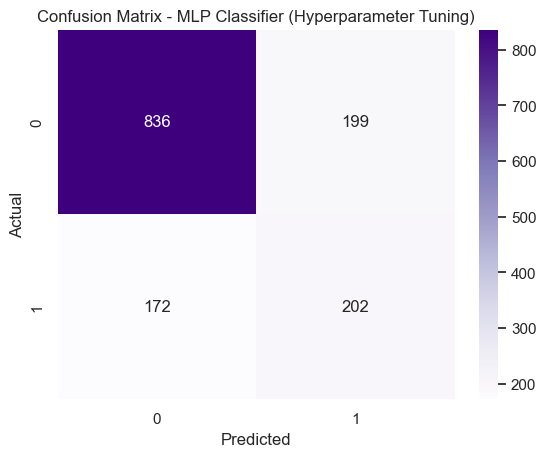

In [251]:
mlphp_cmatrix = confusion_matrix(y_test, mlphp_pred)
sns.heatmap(mlphp_cmatrix, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - MLP Classifier (Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [252]:
mlphp_report = classification_report(y_test, grid_searchmlphp.predict(X_test))
mlphp_f1score = f1_score(y_test, grid_searchmlphp.predict(X_test), average='weighted')
mlphp_accuracy = accuracy_score(y_test, grid_searchmlphp.predict(X_test))
mlphp_roc_auc = roc_auc_score(y_test, grid_searchmlphp.predict_proba(X_test)[:, 1])
mlphp_avg_precision = average_precision_score(y_test, grid_searchmlphp.predict_proba(X_test)[:, 1])

print("Classification Report - MLP Classifier (Hyperparameter Tuning):\n", mlphp_report)
print("F1 Score - MLP Classifier (Hyperparameter Tuning):", mlphp_f1score)
print("Accuracy - MLP Classifier (Hyperparameter Tuning):", mlphp_accuracy)
print("ROC AUC Score - MLP Classifier (Hyperparameter Tuning):", mlphp_roc_auc)
print("Average Precision Score - MLP Classifier (Hyperparameter Tuning):", mlphp_avg_precision)

Classification Report - MLP Classifier (Hyperparameter Tuning):
               precision    recall  f1-score   support

           0       0.83      0.81      0.82      1035
           1       0.50      0.54      0.52       374

    accuracy                           0.74      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409

F1 Score - MLP Classifier (Hyperparameter Tuning): 0.7395394171717111
Accuracy - MLP Classifier (Hyperparameter Tuning): 0.7366926898509581
ROC AUC Score - MLP Classifier (Hyperparameter Tuning): 0.7649177193934226
Average Precision Score - MLP Classifier (Hyperparameter Tuning): 0.5159702430336588


In [253]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'MLP Classifier']
f1_scores = [lr_f1score, rf_f1score, gb_f1score, mlp_f1score]
f1_scores_smote = [lrs_f1score, rfs_f1score, gbs_f1score, mlps_f1score]
f1_scores_hp = [lrhp_f1score, rfhp_f1score, gbhp_f1score, mlphp_f1score]
compare_f1 = pd.DataFrame({'Algorithm': models, 'F1 Score Before SMOTE': f1_scores, 'F1 Score After SMOTE': f1_scores_smote, 'F1 Score After Hyperparameter Tuning': f1_scores_hp})
compare_f1.sort_values(by='F1 Score After Hyperparameter Tuning', ascending=False).reset_index(drop=True)


,Algorithm,F1 Score Before SMOTE,F1 Score After SMOTE,F1 Score After Hyperparameter Tuning
0,Random Forest,0.778713,0.779557,0.775298
1,Gradient Boosting,0.798749,0.779659,0.770231
2,Logistic Regression,0.802109,0.749641,0.752170
3,MLP Classifier,0.765732,0.765560,0.739539
